# DPC 실행 노트북 — epoch 049~299 루프 + MPC/RMPC 동일 noise/disturbance

- 모델 체크포인트 **epoch 49,99,149,199,249,299** 를 자동 루프.
- sensor noise / laser-power disturbance 를 **MPC·RMPC와 정확히 동일**하게 주입 (노이즈 seed=1000 동일).
- 환경 4조건 `base / noise / dist / both` 를 플래그로 전환, 저장 폴더도 조건별로 분리.
- plant 입력 = `u_cmd + d` (미측정 외란). 분석용으로 `u_cmd / u_plant / disturbance / x_true` 모두 저장.

**실행 전**: `MODEL_DIR`, `SPLIT_DIR` 경로와 `LASER_NUMS` 를 환경에 맞게 확인하세요.


In [1]:
# ===== imports =====
import os, sys, time, copy, warnings, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm

warnings.filterwarnings("ignore")
import logging; logging.disable(logging.CRITICAL)

sys.path.append('../1_model')
from TiDE import TideModule, quantile_loss, TiDE_forward
from nn_functions import surrogate
from moving_average import moving_average_1d
from GAMMA_obj_temp_depth import GAMMA_obj

import importlib, policy
importlib.reload(policy)
from policy import PolicyNN

device = torch.device("cpu")
print("cuda available:", torch.cuda.is_available())


cuda available: True


In [2]:
# ===== normalization (x_min/x_max, fns) =====
x_min = torch.tensor([[0.0, 0.75, 0.75, 504.26]], dtype=torch.float32).to(device)
x_max = torch.tensor([[7.5, 20.0, 20.0, 732.298]], dtype=torch.float32).to(device)
y_min = torch.tensor([[436.608, -0.559]], dtype=torch.float32).to(device)
y_max = torch.tensor([[4509.855, 0.551]], dtype=torch.float32).to(device)

def normalize_x(x, dim_id):
    return 2*(x - x_min[0, dim_id])/(x_max[0, dim_id] - x_min[0, dim_id]) - 1
def inverse_normalize_x(x_norm, dim_id):
    return 0.5*(x_norm + 1)*(x_max[0, dim_id] - x_min[0, dim_id]) + x_min[0, dim_id]
def normalize_y(y, dim_id):
    return 2*(y - y_min[0, dim_id])/(y_max[0, dim_id] - y_min[0, dim_id]) - 1
def inverse_normalize_y(y_norm, dim_id):
    return 0.5*(y_norm + 1)*(y_max[0, dim_id] - y_min[0, dim_id]) + y_min[0, dim_id]


## noise / disturbance 설정 (MPC·RMPC와 동일)

In [3]:
# ===== sensor noise + input disturbance config (MPC/RMPC와 정확히 동일) =====
# ---- sensor noise ----
ADD_MEAS_NOISE  = True                              # 조건에 따라 매트릭스 셀에서 토글
MEAS_NOISE_MODE = "absolute"
MEAS_NOISE_STD  = {"temp": 20.0, "depth": 0.005}    # MPC/RMPC: meas_noise_std=(20.0, 0.005)
MEAS_NOISE_REL  = {"temp": 0.01, "depth": 0.02}
NOISE_SEED      = 1000                               # ★ MPC/RMPC와 동일 seed (laser_num 더하지 않음)

def add_meas_noise(temp, depth, rng=None):
    t, d = float(temp), float(depth)
    if not ADD_MEAS_NOISE:
        return t, d
    g = rng if rng is not None else np.random
    if MEAS_NOISE_MODE == "relative":
        t_std, d_std = abs(t)*MEAS_NOISE_REL["temp"], abs(d)*MEAS_NOISE_REL["depth"]
    else:
        t_std, d_std = MEAS_NOISE_STD["temp"], MEAS_NOISE_STD["depth"]
    # 순서(temp->depth), 횟수(2/step) 가 MPC/RMPC와 동일해야 epsilon 시퀀스 일치
    t_noisy = t + float(g.normal(0.0, t_std))
    d_noisy = d + float(g.normal(0.0, d_std))
    return t_noisy, d_noisy

# ---- input(laser power) disturbance presets ----
def dist_step(mag, t_on):  return lambda step, u_cmd, rng: (mag if step >= t_on else 0.0)
def dist_pulse(mag, a, b): return lambda step, u_cmd, rng: (mag if a <= step < b else 0.0)
def dist_bias(mag):        return lambda step, u_cmd, rng: mag
def dist_sine(amp, T, ph=0.0): return lambda step, u_cmd, rng: amp*np.sin(2*np.pi*step/T + ph)
def dist_gauss(std):       return lambda step, u_cmd, rng: float(rng.normal(0.0, std))
def dist_rel_bias(frac):   return lambda step, u_cmd, rng: frac*u_cmd

ADD_INPUT_DISTURBANCE  = True                        # 조건에 따라 토글
DISTURBANCE_FN         = dist_step(50.0, 3000)       # ★ MPC/RMPC와 동일: step>=3000 부터 +50W
DIST_SEED              = 2000
DISTURBANCE_IN_HISTORY = False                        # 미측정 외란 (컨트롤러는 d 모름)
CLIP_PLANT_INPUT       = False


## run_one_step_policy (입력 disturbance 주입 포함)

In [4]:
# ===== one closed-loop step (policy) =====
def run_one_step_policy(GAMMA_obj, policy_model, P, window):
    mp_temp_ref = GAMMA_obj.ref[GAMMA_obj.MPC_counter:GAMMA_obj.MPC_counter + P]
    mp_temp_ref_t = torch.as_tensor(mp_temp_ref, dtype=torch.float32, device=device).reshape(1, P, 1)

    mp_temp_past_t = GAMMA_obj.x_past.T.unsqueeze(0).to(device)
    laser_past_t   = GAMMA_obj.u_past.view(1, -1, 1).to(device)
    fix_cov_past   = GAMMA_obj.fix_cov_all[GAMMA_obj.MPC_counter - window:GAMMA_obj.MPC_counter, :]
    fix_cov_past_t = torch.as_tensor(fix_cov_past, dtype=torch.float32, device=device).unsqueeze(0)

    fix_cov_past_s = normalize_x(fix_cov_past_t, dim_id=[0, 1, 2])
    laser_past_s   = normalize_x(laser_past_t, dim_id=[3])
    mp_temp_past_s = normalize_y(mp_temp_past_t, dim_id=[0, 1])
    policy_in_past = torch.cat((fix_cov_past_s, laser_past_s, mp_temp_past_s), dim=2)

    fix_cov_future   = GAMMA_obj.fix_cov_all[GAMMA_obj.MPC_counter:GAMMA_obj.MPC_counter + P, :]
    fix_cov_future_t = torch.as_tensor(fix_cov_future, dtype=torch.float32, device=device).unsqueeze(0)
    fix_cov_future_s = normalize_x(fix_cov_future_t, dim_id=[0, 1, 2])
    mp_temp_ref_s    = normalize_y(mp_temp_ref_t, dim_id=[0])[:, :, 0].unsqueeze(-1)

    depth_lower_const, depth_upper_const = 0.1423, 0.4126
    y_const_s = torch.tensor([[depth_lower_const, depth_upper_const]]*P, dtype=torch.float32, device=device).reshape(1, P, 2)
    policy_in_future = torch.cat((fix_cov_future_s, mp_temp_ref_s, y_const_s), dim=2)

    t1 = time.time()
    u_pred = policy_model((policy_in_past, policy_in_future))
    t2 = time.time()
    GAMMA_obj.save_time.append(t2 - t1)

    u_first = u_pred[0, 0]
    u_prev  = normalize_x(GAMMA_obj.u_past[-1].view(1, 1, 1).to(device), dim_id=[3])[0, 0, 0]

    # delta clamp (rate limit)
    delta_max = 0.05
    delta_clamped = torch.clamp(u_first - u_prev, -delta_max, delta_max)
    u_first_limited = u_prev + delta_clamped
    u_cmd = float(inverse_normalize_x(u_first_limited, dim_id=[3]))      # 정책 명령값

    # ----- 입력 disturbance 주입 (MPC/RMPC와 동일 규약) -----
    d = 0.0
    if ADD_INPUT_DISTURBANCE and (DISTURBANCE_FN is not None):
        dist_rng = getattr(GAMMA_obj, "dist_rng", None)
        d = float(DISTURBANCE_FN(GAMMA_obj.MPC_counter, u_cmd, dist_rng))  # 증가 전 MPC_counter로 키잉
    u_plant = u_cmd + d
    if CLIP_PLANT_INPUT:
        u_plant = min(max(u_plant, float(x_min[0, 3])), float(x_max[0, 3]))

    # plant(GAMMA)에는 교란된 입력
    x_true, depth_true = GAMMA_obj.run_sim_interval(u_plant)

    # 측정 노이즈 (참값에 가산)
    rng = getattr(GAMMA_obj, "meas_rng", None)
    x_current, depth_current = add_meas_noise(x_true, depth_true, rng=rng)

    GAMMA_obj.x_past[:, :-1] = GAMMA_obj.x_past[:, 1:]
    GAMMA_obj.x_past[0, -1] = x_current
    GAMMA_obj.x_past[1, -1] = depth_current

    u_hist = u_plant if DISTURBANCE_IN_HISTORY else u_cmd
    GAMMA_obj.u_past[:-1] = GAMMA_obj.u_past[1:].clone()
    GAMMA_obj.u_past[-1] = u_hist

    GAMMA_obj.x_hat_current = torch.tensor([x_current, depth_current], device=device)
    GAMMA_obj.x_sys_current = torch.tensor([[x_current], [depth_current]], device=device)
    GAMMA_obj.MPC_counter += 1

    # 저장
    GAMMA_obj.x_past_save = torch.cat((GAMMA_obj.x_past_save,
        torch.tensor([[x_current, depth_current]], device=GAMMA_obj.x_past_save.device)), dim=0)
    GAMMA_obj.u_past_save = torch.cat((GAMMA_obj.u_past_save,
        torch.tensor([[u_hist]], device=GAMMA_obj.u_past_save.device)), dim=0)
    GAMMA_obj.x_true_save = torch.cat((GAMMA_obj.x_true_save,
        torch.tensor([[x_true, depth_true]], device=GAMMA_obj.x_true_save.device)), dim=0)
    GAMMA_obj.u_cmd_save = torch.cat((GAMMA_obj.u_cmd_save,
        torch.tensor([[u_cmd]], device=GAMMA_obj.u_cmd_save.device)), dim=0)
    GAMMA_obj.u_plant_save = torch.cat((GAMMA_obj.u_plant_save,
        torch.tensor([[u_plant]], device=GAMMA_obj.u_plant_save.device)), dim=0)
    GAMMA_obj.disturbance_save = torch.cat((GAMMA_obj.disturbance_save,
        torch.tensor([[d]], device=GAMMA_obj.disturbance_save.device)), dim=0)


In [5]:
# ===== plot helper =====
def plot_fig(G, N_step, save_path=None):
    plt.figure(figsize=[8, 6])
    plt.subplot(3, 1, 1)
    plt.plot(G.x_past_save[:N_step, 0].detach().cpu().numpy(), label="GAMMA")
    plt.plot(G.ref[:N_step].detach().cpu().numpy(), label="Reference")
    plt.ylabel("MP Temp (K)"); plt.legend()
    plt.subplot(3, 1, 2)
    plt.plot(G.x_past_save[:N_step, 1].detach().cpu().numpy(), label="GAMMA")
    plt.plot(np.arange(N_step), 0.225*np.ones(N_step), '--', label="UB")
    plt.plot(np.arange(N_step), 0.075*np.ones(N_step), '--', label="LB")
    plt.ylabel("MP Depth (mm)"); plt.legend()
    plt.subplot(3, 1, 3)
    plt.plot(G.u_plant_save[:N_step].detach().cpu().numpy(), label="u_plant")
    plt.plot(G.u_cmd_save[:N_step].detach().cpu().numpy(), '--', label="u_cmd")
    plt.ylabel("Laser power (W)"); plt.xlabel("MPC step"); plt.legend()
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight"); plt.close()
    else:
        plt.show()


## 경로/상수 + run_epoch 함수

In [6]:
# ===== constants & paths =====
INPUT_DATA_DIR = "data"
SIM_DIR_NAME   = "single_track_square"
BASE_LASER_FILE_DIR = "laser_power_profiles/csv"
CLOUD_TARGET_BASE_PATH = "result"
solidus_temp = 1600
window = 50
sim_interval = 5
init_runs = 50
P = 50

# 모델 체크포인트들이 들어있는 디렉토리 (epoch별 policy_roll_epoch{E:04d}.pth)
MODEL_DIR = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff"
SPLIT_DIR = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/split_by_laser_power_number"

LASER_NUMS = range(1, 2)     # 필요시 넓히기

def _cond_tag():
    if ADD_MEAS_NOISE and ADD_INPUT_DISTURBANCE: return "both"
    if ADD_MEAS_NOISE:        return "noise"
    if ADD_INPUT_DISTURBANCE: return "dist"
    return "base"

def build_model(model_path):
    m = PolicyNN(past_input_dim=6, future_input_dim=6, output_dim=1,
                 p=P, window=window, hidden_dim=1024, n_layers=3, dropout_p=0.0).to(device)
    m.load_state_dict(torch.load(model_path, map_location=device))
    m.eval()
    return m


In [7]:
# ===== run a single epoch (현재 noise/disturbance 플래그 기준) =====
def run_epoch(epoch, cond_name=None, laser_nums=None, plot_every=500):
    if cond_name is None:  cond_name = _cond_tag()
    if laser_nums is None: laser_nums = LASER_NUMS

    model_path = os.path.join(MODEL_DIR, f"policy_roll_epoch{epoch:04d}.pth")
    save_dir   = os.path.join(MODEL_DIR, "time", cond_name, f"policy_roll_epoch{epoch:04d}.pth_clamped(1)")
    os.makedirs(save_dir, exist_ok=True)
    model = build_model(model_path)

    for laser_num in laser_nums:
        try:
            df = pd.read_csv(os.path.join(SPLIT_DIR, f"laser_power_number_{laser_num}.csv"))

            GAMMA_class = GAMMA_obj(INPUT_DATA_DIR, SIM_DIR_NAME, BASE_LASER_FILE_DIR,
                                    CLOUD_TARGET_BASE_PATH, solidus_temp, window,
                                    init_runs, sim_interval, laser_power_number=laser_num)
            init_avg = GAMMA_class.run_initial_steps()
            init_avg = torch.tensor(init_avg, dtype=torch.float32).to(device)[:, -window:]

            loc_Z  = df["Z"].to_numpy().reshape(-1, 1)
            dist_X = df["Dist_to_nearest_X"].to_numpy().reshape(-1, 1)
            dist_Y = df["Dist_to_nearest_Y"].to_numpy().reshape(-1, 1)
            fix_covariates = torch.tensor(np.concatenate((loc_Z, dist_X, dist_Y), axis=1), dtype=torch.float32).to(device)
            laser_power_ref  = torch.tensor(df["Laser_power"].to_numpy().reshape(-1, 1), dtype=torch.float32).to(device)
            laser_power_past = laser_power_ref[:window]
            mp_temp_raw = df["melt_pool_temperature"].to_numpy()
            mp_temp = copy.deepcopy(mp_temp_raw); mp_temp[1:-2] = moving_average_1d(mp_temp_raw, 4)
            mp_temp_ref = torch.tensor(mp_temp, dtype=torch.float32).to(device)

            # init GAMMA state
            GAMMA_class.ref = mp_temp_ref.clone().to(device)
            GAMMA_class.fix_cov_all = fix_covariates.clone().to(device)
            GAMMA_class.x_past = init_avg.clone().to(device)
            GAMMA_class.u_past = laser_power_past.clone().to(device)
            GAMMA_class.x_past_save = GAMMA_class.x_past.T.clone().to(device)
            GAMMA_class.u_past_save = GAMMA_class.u_past.clone().to(device)
            GAMMA_class.MPC_counter = window
            GAMMA_class.x_hat_current = GAMMA_class.x_past[:, -1].to(device)
            GAMMA_class.x_sys_current = GAMMA_class.x_past[:, -1].reshape(2, 1).to(device)
            GAMMA_class.save_time = []

            # ★ MPC/RMPC와 동일 seed + 외란 rng + 분석 버퍼
            GAMMA_class.meas_rng = np.random.default_rng(NOISE_SEED)
            GAMMA_class.dist_rng = np.random.default_rng(DIST_SEED)
            GAMMA_class.x_true_save      = GAMMA_class.x_past_save.clone()
            GAMMA_class.u_cmd_save       = GAMMA_class.u_past_save.clone()
            GAMMA_class.u_plant_save     = GAMMA_class.u_past_save.clone()
            GAMMA_class.disturbance_save = torch.zeros_like(GAMMA_class.u_past_save)

            N_step = len(mp_temp_ref) - P
            for i in tqdm(range(N_step - P), desc=f"ep{epoch:04d} L{laser_num} [{cond_name}]"):
                run_one_step_policy(GAMMA_class, model, P=P, window=window)
                if plot_every and i % plot_every == 0:
                    plot_fig(GAMMA_class, N_step)
            plot_fig(GAMMA_class, N_step, save_path=os.path.join(save_dir, f"final_plot_laser_{laser_num}.png"))

            # save outputs
            def save(arr, name):
                pd.DataFrame(arr.detach().cpu().numpy()).to_csv(os.path.join(save_dir, name), index=False)
            save(GAMMA_class.x_past_save,     f"x_outputs_laser_{laser_num}.csv")
            save(GAMMA_class.u_past_save,     f"u_outputs_laser_{laser_num}.csv")
            save(GAMMA_class.ref.reshape(-1,1), f"ref_laser_{laser_num}.csv")
            save(GAMMA_class.x_true_save,     f"x_true_outputs_laser_{laser_num}.csv")
            save(GAMMA_class.u_cmd_save,      f"u_cmd_laser_{laser_num}.csv")
            save(GAMMA_class.u_plant_save,    f"u_plant_laser_{laser_num}.csv")
            save(GAMMA_class.disturbance_save,f"disturbance_laser_{laser_num}.csv")
            pd.DataFrame({'Time': GAMMA_class.save_time}).to_csv(
                os.path.join(save_dir, f"policy_time_laser_{laser_num}.csv"), index=False)

            print(f"✅ epoch {epoch:04d} laser {laser_num} [{cond_name}] done -> {save_dir}")
        except Exception as e:
            print(f"❌ epoch {epoch:04d} laser {laser_num} [{cond_name}]: {e}")


## ▶ epoch 049~299 루프 실행

epochs: [49, 99, 149, 199, 249, 299] | 현재 조건: both


ep0049 L1 [both]:   0%|          | 0/6195 [00:00<?, ?it/s]

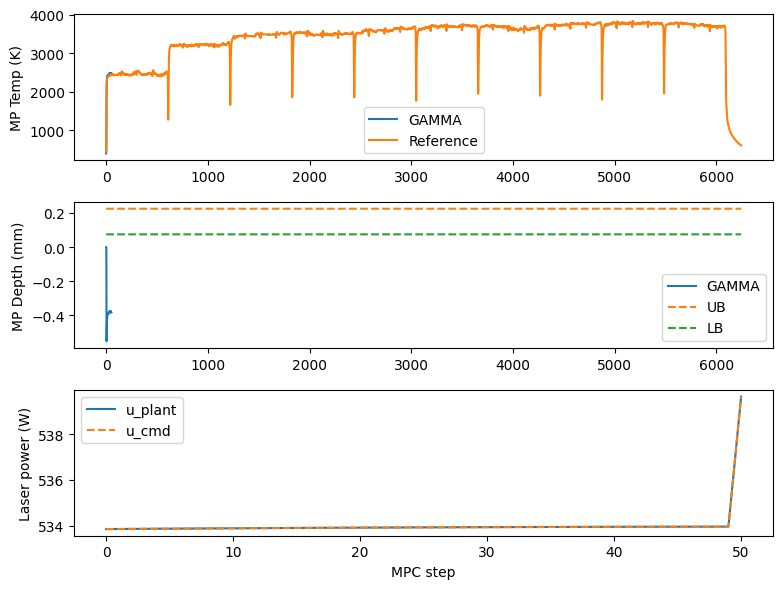

ep0049 L1 [both]:   5%|▌         | 327/6195 [00:40<12:04,  8.10it/s]


KeyboardInterrupt: 

In [8]:
# ===== epoch loop =====
EPOCHS = list(range(49, 300, 50))    # [49, 99, 149, 199, 249, 299]
print("epochs:", EPOCHS, "| 현재 조건:", _cond_tag())

for epoch in EPOCHS:
    run_epoch(epoch)


## ▶ (선택) 4조건 × 6에폭 = 24런 한 번에

`base / noise / dist / both` 를 모두 돌립니다. 저장 폴더가 조건별로 분리되어 안 겹칩니다.
오래 걸리니 필요할 때만.

ep0049 L1 [both]:   0%|          | 0/6195 [00:00<?, ?it/s]

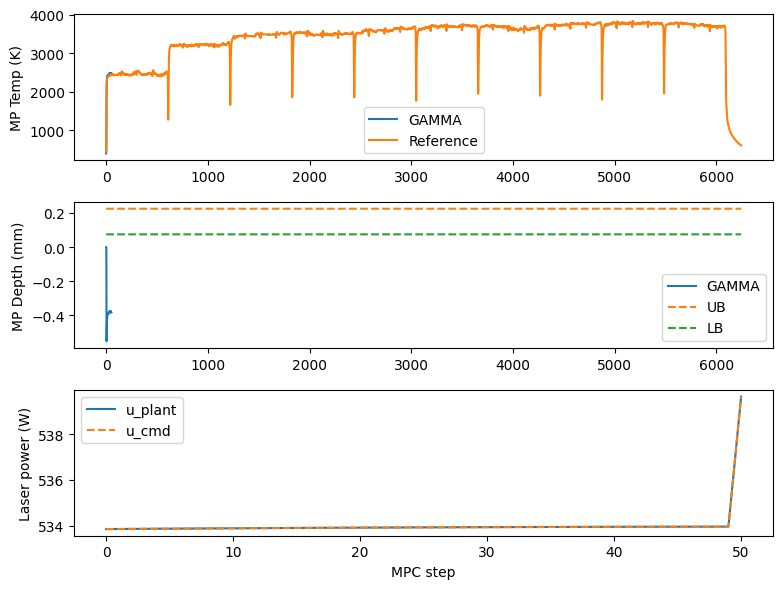

ep0049 L1 [both]:   8%|▊         | 500/6195 [01:01<12:09,  7.80it/s]

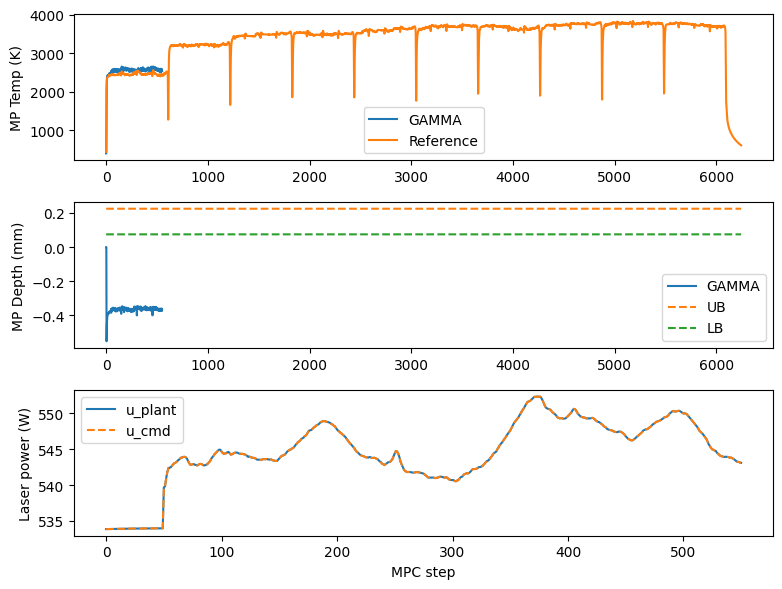

ep0049 L1 [both]:  16%|█▌        | 1000/6195 [02:07<12:40,  6.83it/s]

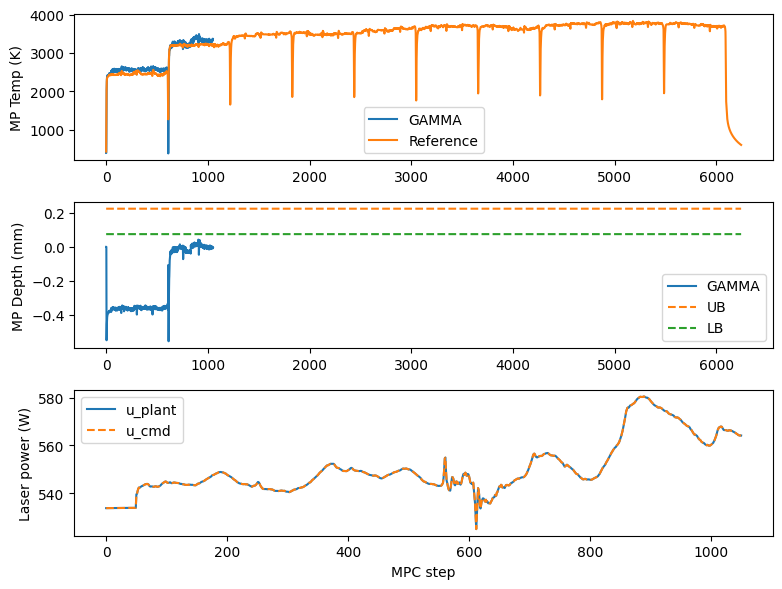

ep0049 L1 [both]:  24%|██▍       | 1500/6195 [03:17<11:20,  6.90it/s]

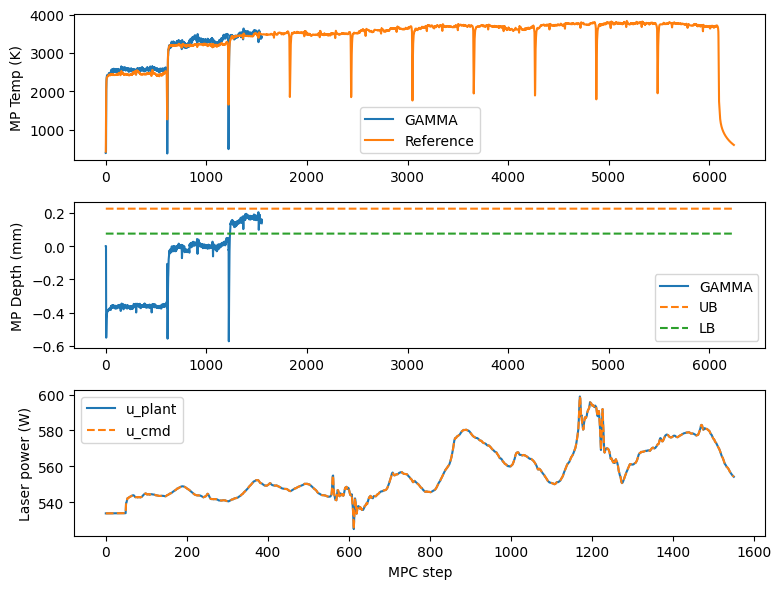

ep0049 L1 [both]:  32%|███▏      | 2000/6195 [04:29<10:10,  6.88it/s]

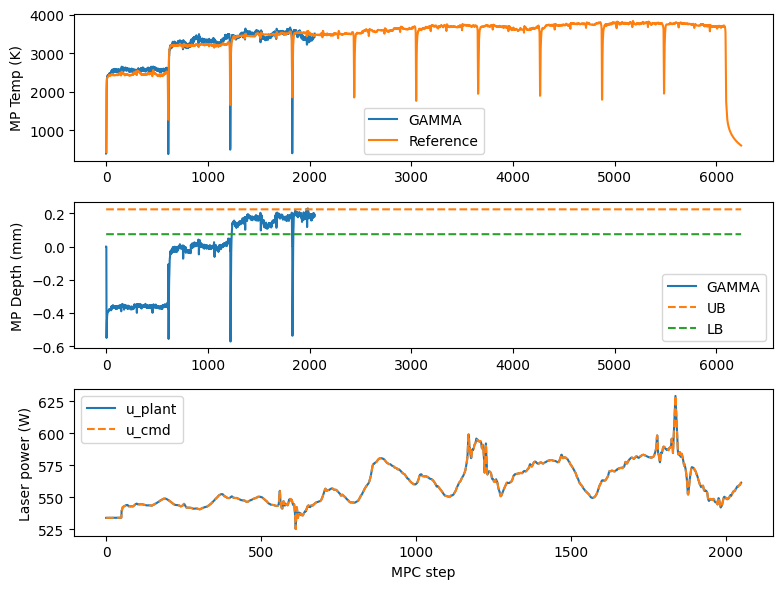

ep0049 L1 [both]:  40%|████      | 2500/6195 [05:44<09:03,  6.80it/s]

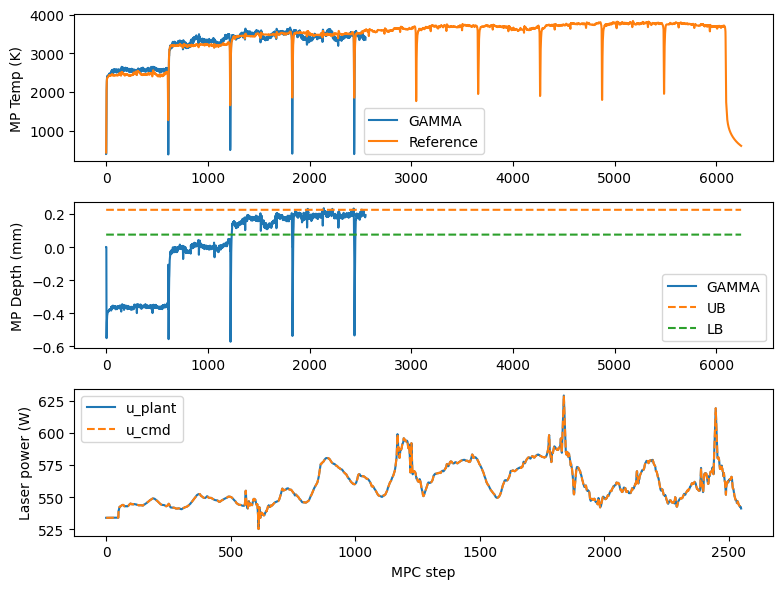

ep0049 L1 [both]:  48%|████▊     | 3000/6195 [07:00<07:28,  7.13it/s]

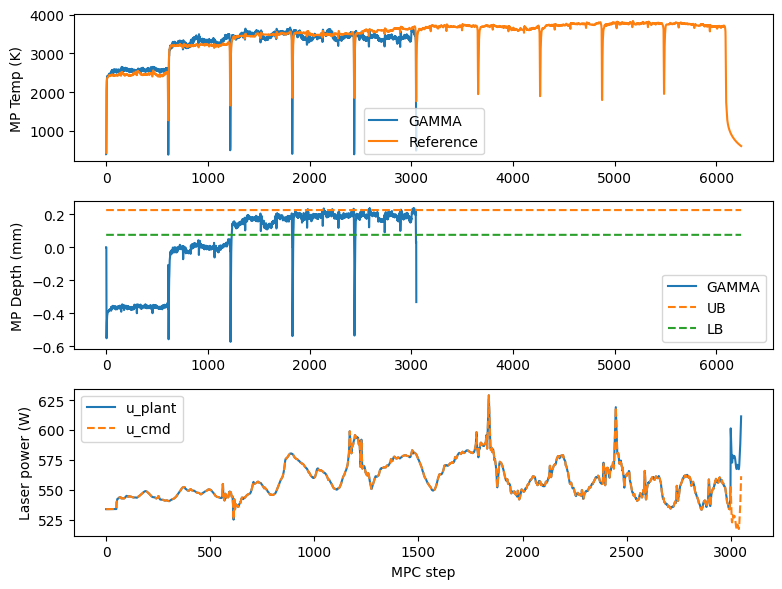

ep0049 L1 [both]:  56%|█████▋    | 3500/6195 [08:18<06:39,  6.74it/s]

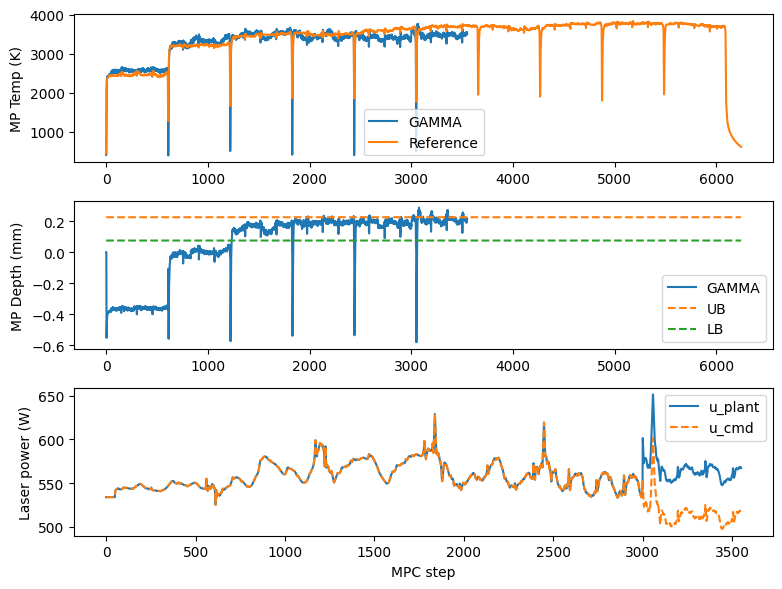

ep0049 L1 [both]:  65%|██████▍   | 4000/6195 [09:35<05:52,  6.23it/s]

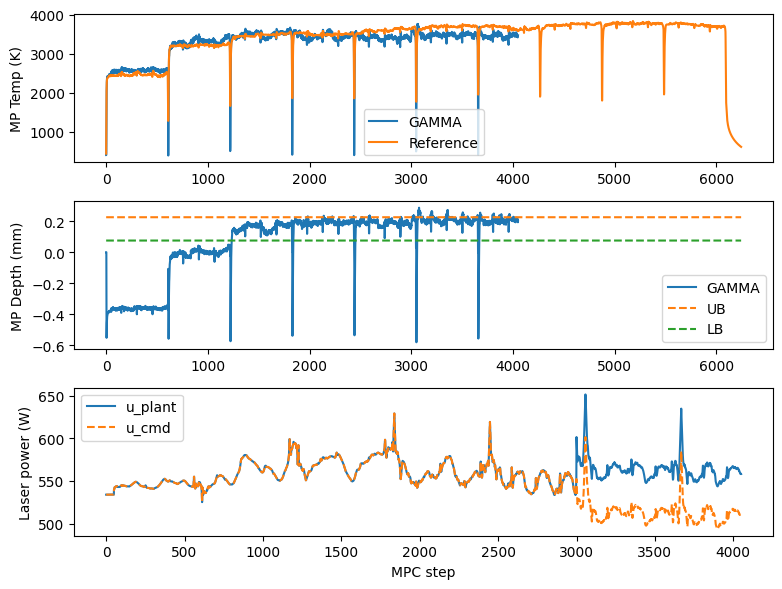

ep0049 L1 [both]:  73%|███████▎  | 4500/6195 [10:53<04:24,  6.41it/s]

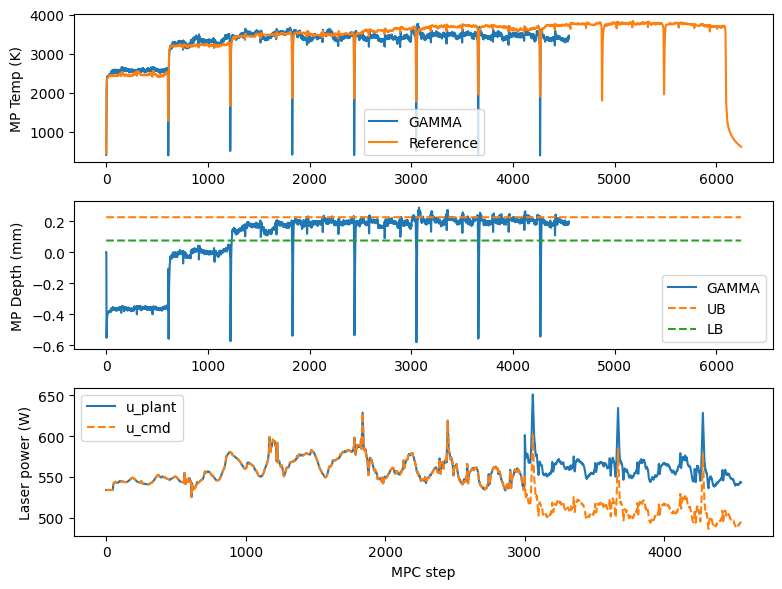

ep0049 L1 [both]:  81%|████████  | 5000/6195 [12:13<03:12,  6.22it/s]

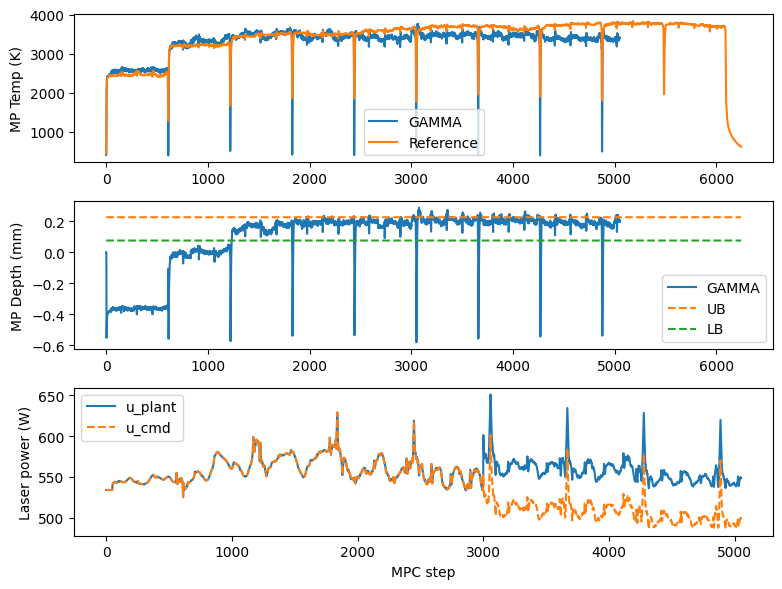

ep0049 L1 [both]:  89%|████████▉ | 5500/6195 [13:46<02:32,  4.57it/s]

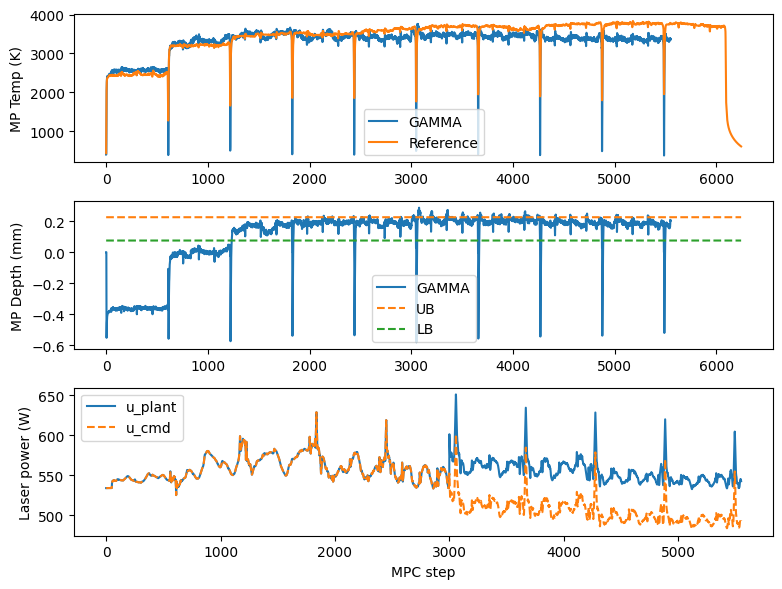

ep0049 L1 [both]:  97%|█████████▋| 6000/6195 [15:07<00:31,  6.16it/s]

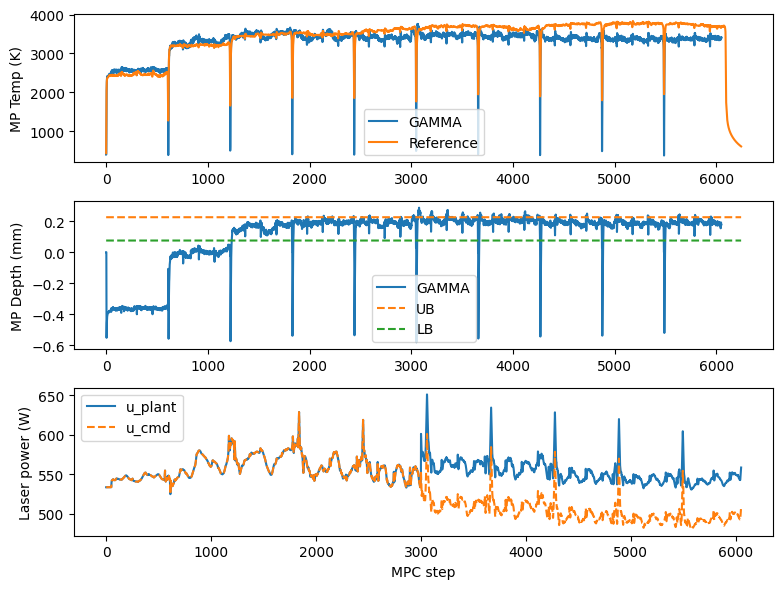

ep0049 L1 [both]: 100%|██████████| 6195/6195 [15:36<00:00,  6.62it/s]


✅ epoch 0049 laser 1 [both] done -> /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/both/policy_roll_epoch0049.pth_clamped(1)


ep0099 L1 [both]:   0%|          | 0/6195 [00:00<?, ?it/s]

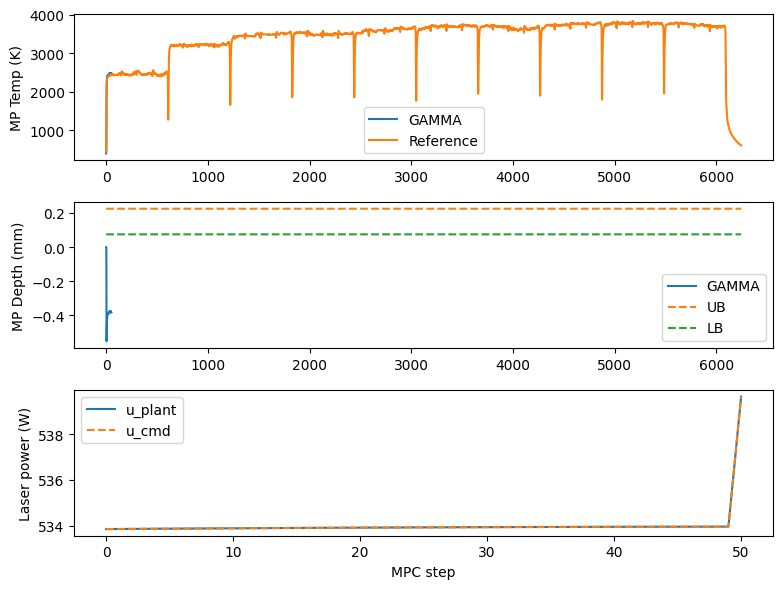

ep0099 L1 [both]:   8%|▊         | 500/6195 [01:04<12:27,  7.62it/s]

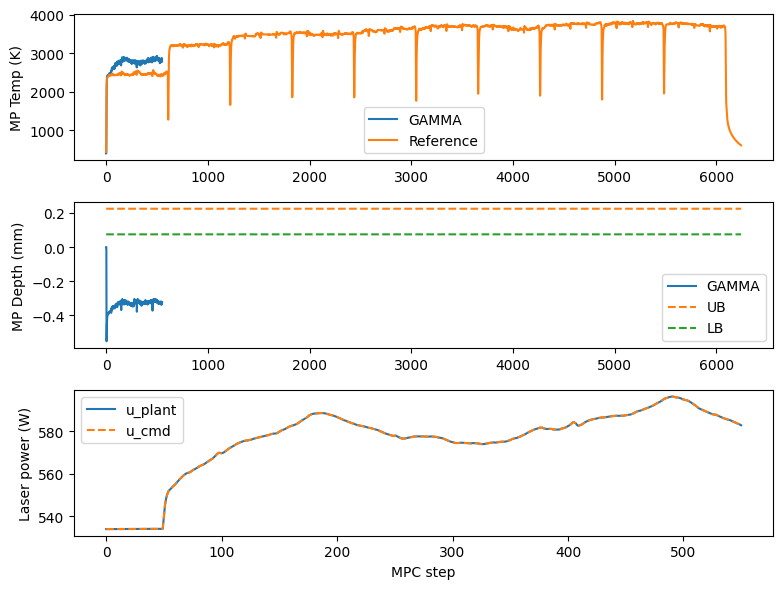

ep0099 L1 [both]:  16%|█▌        | 1000/6195 [02:11<11:34,  7.48it/s]

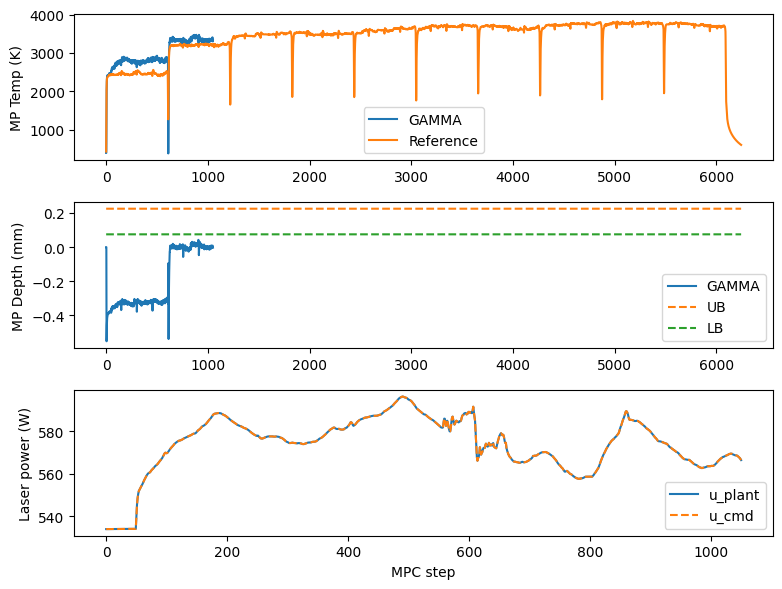

ep0099 L1 [both]:  24%|██▍       | 1500/6195 [03:21<10:39,  7.34it/s]

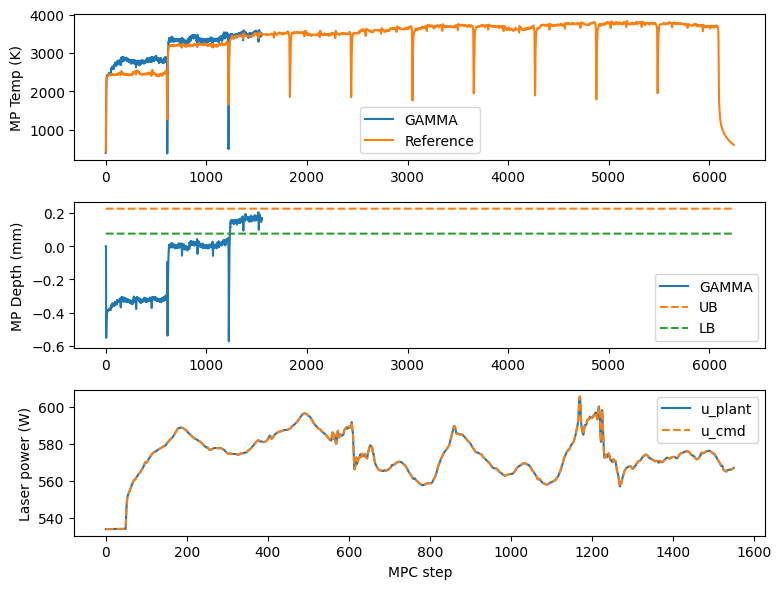

ep0099 L1 [both]:  32%|███▏      | 2000/6195 [04:33<10:22,  6.74it/s]

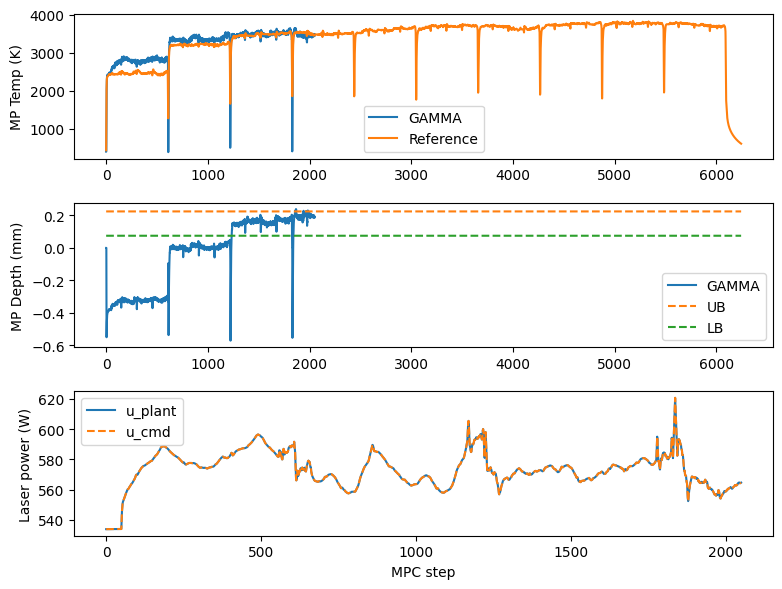

ep0099 L1 [both]:  40%|████      | 2500/6195 [05:45<09:08,  6.74it/s]

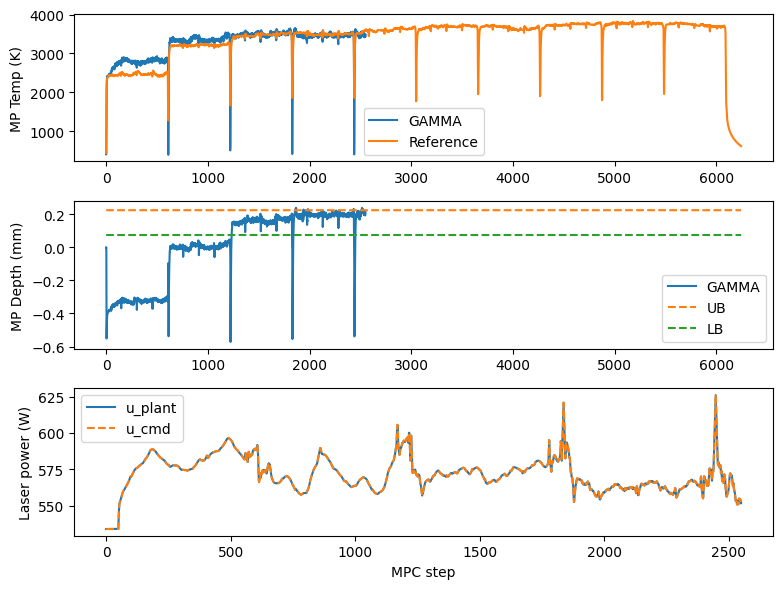

ep0099 L1 [both]:  48%|████▊     | 3000/6195 [07:00<07:20,  7.25it/s]

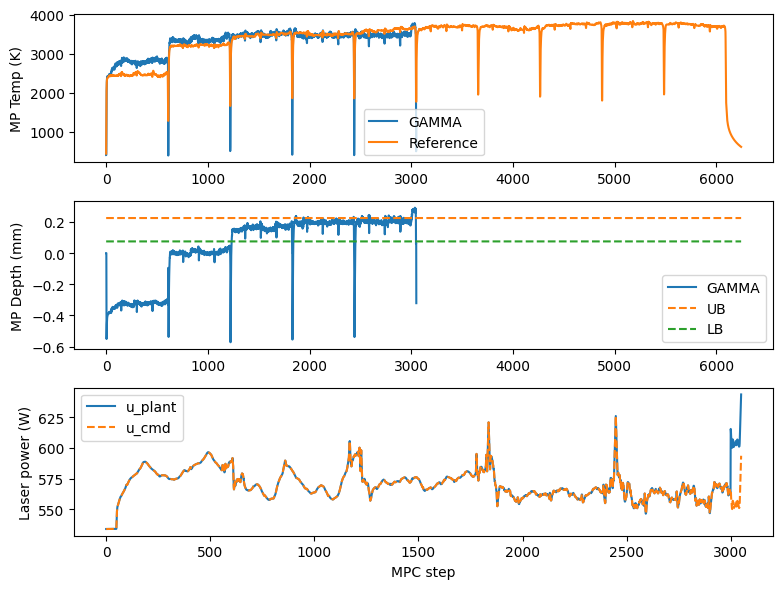

ep0099 L1 [both]:  56%|█████▋    | 3500/6195 [08:16<06:43,  6.68it/s]

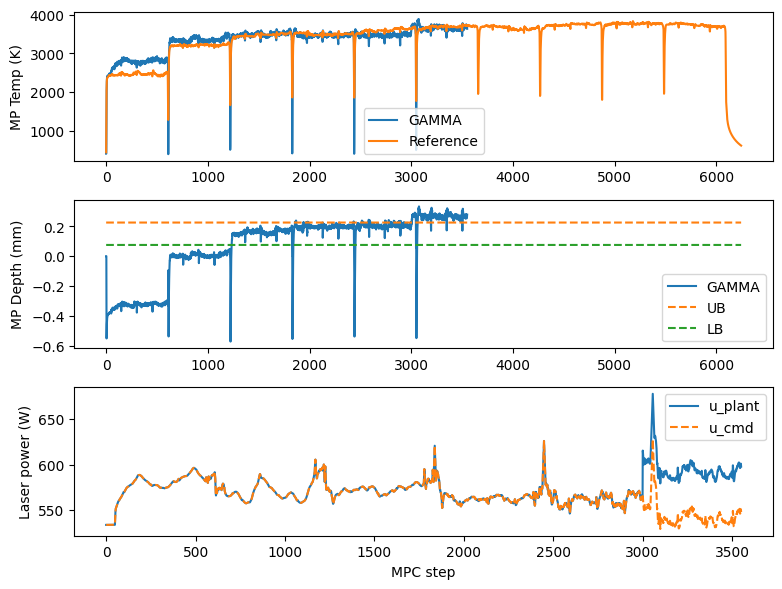

ep0099 L1 [both]:  65%|██████▍   | 4000/6195 [09:32<05:32,  6.60it/s]

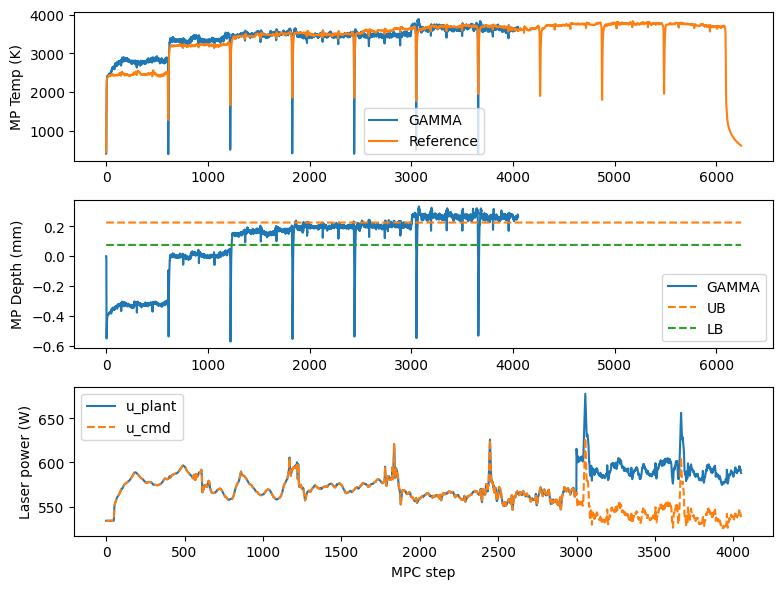

ep0099 L1 [both]:  73%|███████▎  | 4500/6195 [10:49<04:32,  6.21it/s]

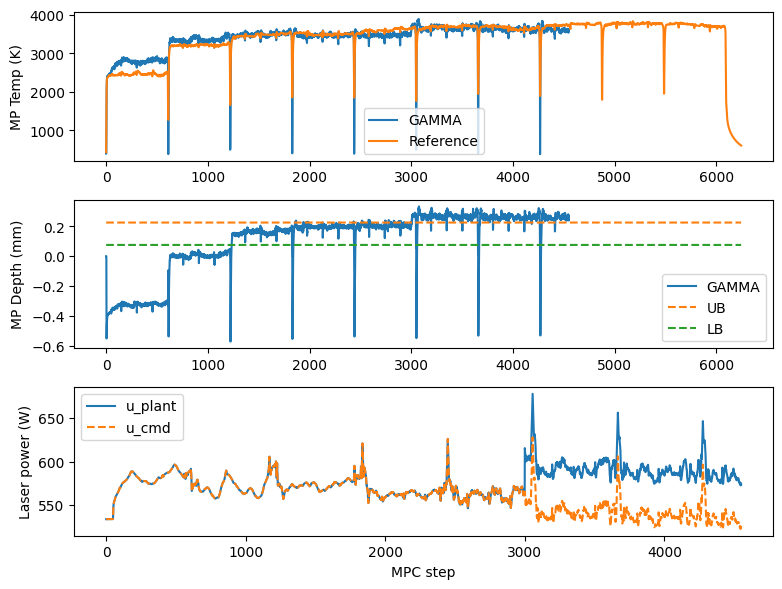

ep0099 L1 [both]:  81%|████████  | 5000/6195 [12:09<03:23,  5.86it/s]

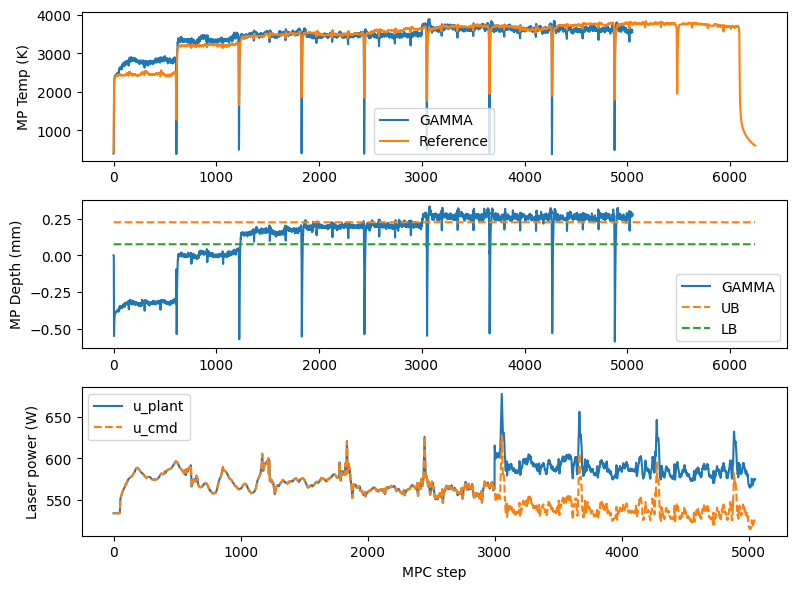

ep0099 L1 [both]:  89%|████████▉ | 5500/6195 [13:28<01:52,  6.21it/s]

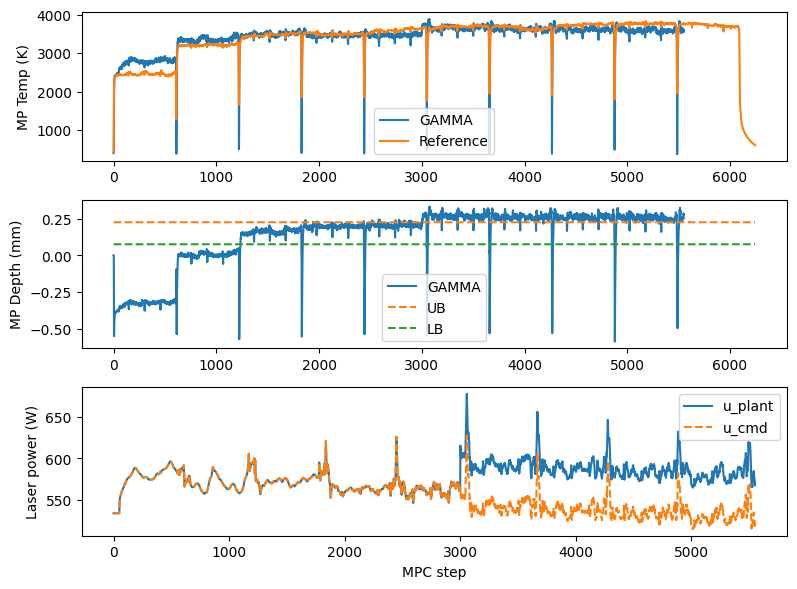

ep0099 L1 [both]:  97%|█████████▋| 6000/6195 [15:03<00:38,  5.13it/s]

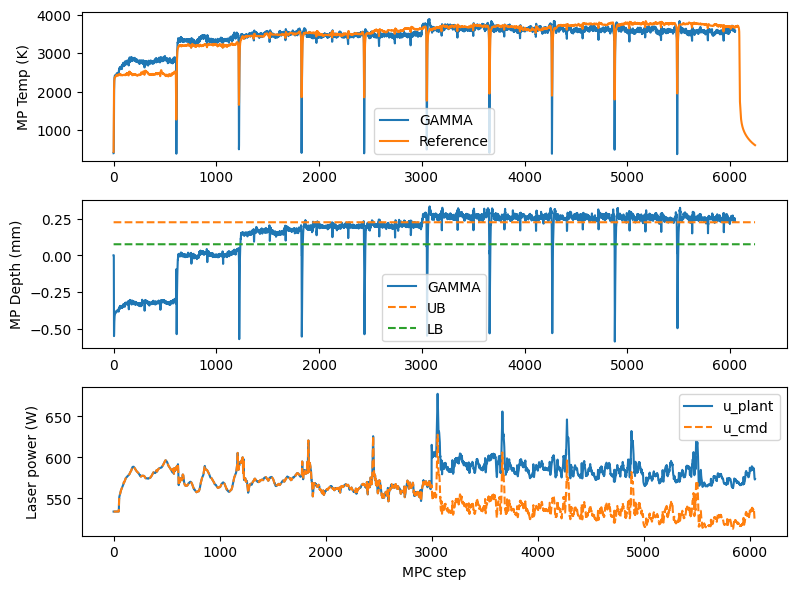

ep0099 L1 [both]: 100%|██████████| 6195/6195 [15:34<00:00,  6.63it/s]


✅ epoch 0099 laser 1 [both] done -> /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/both/policy_roll_epoch0099.pth_clamped(1)


ep0149 L1 [both]:   0%|          | 0/6195 [00:00<?, ?it/s]

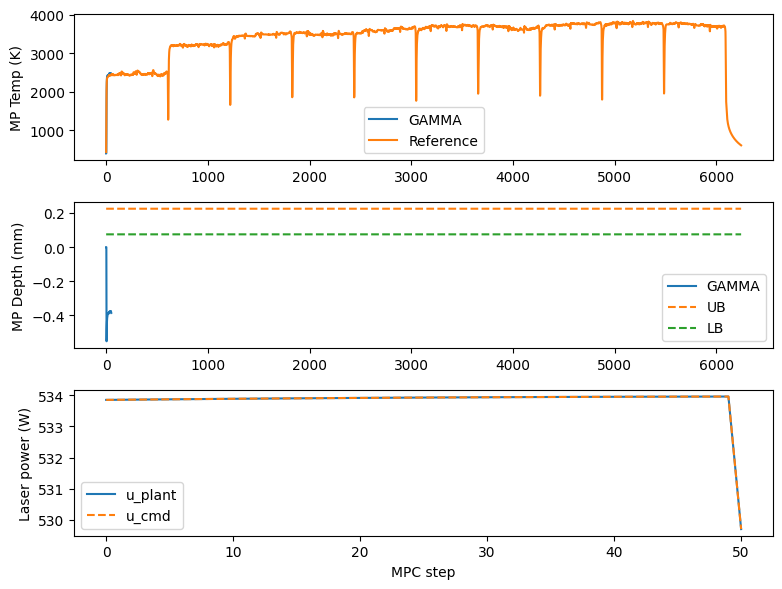

ep0149 L1 [both]:   6%|▌         | 377/6195 [01:09<17:57,  5.40it/s]


KeyboardInterrupt: 

In [10]:
# ===== 전체 매트릭스 (4 conditions x epochs) =====
CONDITIONS = {
    "both":  dict(noise=True,  dist=True),
    "base":  dict(noise=False, dist=False),
    "noise": dict(noise=True,  dist=False),
    "dist":  dict(noise=False, dist=True)
}
for cond_name, c in CONDITIONS.items():
    ADD_MEAS_NOISE        = c["noise"]      # 전역 토글
    ADD_INPUT_DISTURBANCE = c["dist"]
    for epoch in EPOCHS:
        run_epoch(epoch, cond_name=cond_name)
